In [ ]:
# Financial Risk Analysis AI Model with Matplotlib-Based Explainability
# Complete Version for Colab

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("🔧 Installing required packages...")
!pip install yfinance scikit-optimize pyportfolioopt --quiet

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
import scipy.stats as stats
import scipy.optimize as sco

print("✅ All packages imported successfully!")

🔧 Installing required packages...
✅ All packages imported successfully!


In [ ]:
# 📊 Data Generation and Feature Engineering
class FinancialDataGenerator:
    def __init__(self):
        self.tickers = ['SPY', 'QQQ', 'IWM', 'TLT', 'GLD', 'VXX', 'USO', 'FXE']
        self.feature_columns = []

    def fetch_market_data(self, period="5y"):
        """Fetch real market data from Yahoo Finance"""
        print("📈 Fetching market data...")
        end_date = datetime.now()
        start_date = end_date - timedelta(days=5*365)

        data = yf.download(self.tickers, start=start_date, end=end_date, auto_adjust=True)
        prices = data['Close'].dropna()

        # Handle volume data carefully
        if 'Volume' in data:
            volumes = data['Volume'].dropna()
            # If volumes is empty or has issues, create synthetic volumes
            if volumes.empty:
                volumes = prices.rolling(20).mean() * 1000000  # Synthetic volume
        else:
            volumes = prices.rolling(20).mean() * 1000000  # Synthetic volume

        return prices, volumes

    def calculate_technical_indicators(self, prices, volumes):
        """Calculate comprehensive technical indicators"""
        print("🔧 Calculating technical indicators...")

        features_dict = {}

        for ticker in prices.columns:
            try:
                price_series = prices[ticker].dropna()

                # Returns
                returns = price_series.pct_change()

                # Volatility features
                volatility_5d = returns.rolling(5).std()
                volatility_21d = returns.rolling(21).std()
                vol_ratio = volatility_5d / (volatility_21d + 1e-8)

                # Momentum features
                momentum_5d = (price_series / price_series.shift(5) - 1).fillna(0)
                momentum_21d = (price_series / price_series.shift(21) - 1).fillna(0)
                rsi = self.calculate_rsi(price_series, 14)

                # Moving averages
                sma_20 = price_series.rolling(20).mean()
                sma_50 = price_series.rolling(50).mean()
                ma_ratio = (sma_20 / sma_50 - 1).fillna(0)

                # Volume features
                if ticker in volumes.columns:
                    volume_series = volumes[ticker]
                else:
                    volume_series = price_series.rolling(20).mean() * 1000000

                volume_sma = volume_series.rolling(20).mean()
                volume_ratio = (volume_series / (volume_sma + 1e-8)).fillna(1)

                # Support/resistance
                rolling_high = price_series.rolling(20).max()
                rolling_low = price_series.rolling(20).min()
                price_range = rolling_high - rolling_low
                support_level = ((price_series - rolling_low) / (price_range + 1e-8)).fillna(0.5)

                # Store features
                features_dict[f'{ticker}_vol_5d'] = volatility_5d
                features_dict[f'{ticker}_vol_21d'] = volatility_21d
                features_dict[f'{ticker}_vol_ratio'] = vol_ratio
                features_dict[f'{ticker}_mom_5d'] = momentum_5d
                features_dict[f'{ticker}_mom_21d'] = momentum_21d
                features_dict[f'{ticker}_rsi'] = rsi
                features_dict[f'{ticker}_ma_ratio'] = ma_ratio
                features_dict[f'{ticker}_volume_ratio'] = volume_ratio
                features_dict[f'{ticker}_support_level'] = support_level

            except Exception as e:
                print(f"⚠️ Error processing {ticker}: {e}")
                continue

        # Create DataFrame and drop NaN values
        features_df = pd.DataFrame(features_dict, index=prices.index)
        features_df = features_df.dropna()

        # Update feature columns
        self.feature_columns = features_df.columns.tolist()

        print(f"✅ Technical indicators calculated: {len(features_df)} samples, {len(features_df.columns)} features")
        return features_df

    def calculate_rsi(self, prices, period=14):
        """Calculate Relative Strength Index"""
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-8)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    def create_target_variables(self, prices, horizon=5):
        """Create multi-horizon target variables"""
        print("🎯 Creating target variables...")

        targets_dict = {}

        for ticker in prices.columns:
            try:
                price_series = prices[ticker].dropna()

                # Future returns (shifted to avoid lookahead bias)
                future_returns = price_series.pct_change(horizon).shift(-horizon)

                # Future volatility
                future_vol = price_series.pct_change().rolling(horizon).std().shift(-horizon)

                # Risk-adjusted return
                risk_adjusted_return = future_returns / (future_vol + 1e-8)

                # Binary classification: positive return
                positive_return = (future_returns > 0).astype(float)

                targets_dict[f'{ticker}_future_return'] = future_returns
                targets_dict[f'{ticker}_future_vol'] = future_vol
                targets_dict[f'{ticker}_risk_adjusted'] = risk_adjusted_return
                targets_dict[f'{ticker}_positive'] = positive_return

            except Exception as e:
                print(f"⚠️ Error creating targets for {ticker}: {e}")
                continue

        targets_df = pd.DataFrame(targets_dict, index=prices.index)
        targets_df = targets_df.dropna()

        print(f"✅ Target variables created: {len(targets_df)} samples")
        return targets_df

In [ ]:
# Initialize and generate dataset
print("🚀 Generating financial dataset...")
generator = FinancialDataGenerator()
prices, volumes = generator.fetch_market_data()
features = generator.calculate_technical_indicators(prices, volumes)
targets = generator.create_target_variables(prices)

# Align datasets properly
common_index = features.index.intersection(targets.index)
features = features.loc[common_index]
targets = targets.loc[common_index]
prices = prices.loc[common_index]

print(f"✅ Final dataset: {len(features)} samples, {len(features.columns)} features")
print(f"📊 Features shape: {features.shape}")
print(f"🎯 Targets shape: {targets.shape}")
print(f"📈 Price data shape: {prices.shape}")

# Display sample of features and targets
print("\n📋 Sample features:")
print(features.iloc[:3, :5])
print("\n📋 Sample targets:")
print(targets.iloc[:3, :4])

🚀 Generating financial dataset...
📈 Fetching market data...


[*********************100%***********************]  8 of 8 completed


🔧 Calculating technical indicators...
✅ Technical indicators calculated: 1235 samples, 72 features
🎯 Creating target variables...
✅ Target variables created: 1251 samples
✅ Final dataset: 1230 samples, 72 features
📊 Features shape: (1230, 72)
🎯 Targets shape: (1230, 32)
📈 Price data shape: (1230, 8)

📋 Sample features:
            FXE_vol_5d  FXE_vol_21d  FXE_vol_ratio  FXE_mom_5d  FXE_mom_21d
Date                                                                       
2020-12-16    0.002894     0.003519       0.822458    0.008722     0.027643
2020-12-17    0.003201     0.003687       0.867987    0.009638     0.033175
2020-12-18    0.002907     0.003709       0.783762    0.010540     0.032579

📋 Sample targets:
            FXE_future_return  FXE_future_vol  FXE_risk_adjusted  FXE_positive
Date                                                                          
2020-12-16           0.000524        0.004854           0.107955           1.0
2020-12-17          -0.006595        0.0033

In [ ]:
# 🏦 Portfolio Risk Analytics Class
class PortfolioRiskAnalyzer:
    def __init__(self, prices):
        self.prices = prices
        self.returns = prices.pct_change().dropna()

    def calculate_portfolio_metrics(self, weights=None):
        """Calculate comprehensive portfolio risk metrics"""
        if weights is None:
            weights = np.ones(len(self.returns.columns)) / len(self.returns.columns)

        portfolio_returns = self.returns.dot(weights)
        portfolio_returns = portfolio_returns.dropna()

        if len(portfolio_returns) == 0:
            return {
                'expected_return': 0,
                'volatility': 0,
                'sharpe_ratio': 0,
                'max_drawdown': 0,
                'var_95': 0,
                'cvar_95': 0,
                'skewness': 0,
                'kurtosis': 0
            }

        metrics = {
            'expected_return': portfolio_returns.mean() * 252,
            'volatility': portfolio_returns.std() * np.sqrt(252),
            'sharpe_ratio': portfolio_returns.mean() / (portfolio_returns.std() + 1e-8) * np.sqrt(252),
            'max_drawdown': self.calculate_max_drawdown(portfolio_returns),
            'var_95': self.calculate_var(portfolio_returns, 0.95),
            'cvar_95': self.calculate_cvar(portfolio_returns, 0.95),
            'skewness': stats.skew(portfolio_returns.fillna(0)),
            'kurtosis': stats.kurtosis(portfolio_returns.fillna(0))
        }

        return metrics

    def calculate_max_drawdown(self, returns):
        """Calculate maximum drawdown"""
        cumulative = (1 + returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        return drawdown.min() if not drawdown.empty else 0

    def calculate_var(self, returns, confidence=0.95):
        """Calculate Value at Risk"""
        returns_clean = returns.dropna()
        if len(returns_clean) == 0:
            return 0
        return np.percentile(returns_clean, (1 - confidence) * 100)

    def calculate_cvar(self, returns, confidence=0.95):
        """Calculate Conditional Value at Risk"""
        returns_clean = returns.dropna()
        if len(returns_clean) == 0:
            return 0
        var = self.calculate_var(returns_clean, confidence)
        return returns_clean[returns_clean <= var].mean()

    def efficient_frontier(self, num_portfolios=1000):
        """Monte Carlo simulation for efficient frontier"""
        returns_clean = self.returns.dropna()
        if len(returns_clean) == 0:
            return np.zeros((3, num_portfolios)), []

        results = np.zeros((3, num_portfolios))
        weights_record = []

        for i in range(num_portfolios):
            weights = np.random.random(len(returns_clean.columns))
            weights /= np.sum(weights)
            weights_record.append(weights)

            portfolio_return = returns_clean.dot(weights)
            portfolio_return_clean = portfolio_return.dropna()

            if len(portfolio_return_clean) > 0:
                annual_return = portfolio_return_clean.mean() * 252
                annual_std = portfolio_return_clean.std() * np.sqrt(252)
                sharpe = annual_return / (annual_std + 1e-8)
            else:
                annual_return, annual_std, sharpe = 0, 0, 0

            results[0,i] = annual_return
            results[1,i] = annual_std
            results[2,i] = sharpe

        return results, weights_record

# Initialize risk analyzer
risk_analyzer = PortfolioRiskAnalyzer(prices)
print("✅ Portfolio Risk Analyzer initialized")

✅ Portfolio Risk Analyzer initialized


In [ ]:
# 🤖 Fully Fixed AI Risk Model
class ExplainableRiskModel:
    def __init__(self, features, targets):
        self.features = features
        self.targets = targets
        self.scaler = StandardScaler()
        self.models = {}
        self.feature_importances = {}
        self.permutation_importances = {}

    def prepare_data(self, test_size=0.2):
        """Prepare train/test split with temporal validation"""
        # Use last portion for testing to avoid lookahead bias
        split_idx = int(len(self.features) * (1 - test_size))

        self.X_train = self.features.iloc[:split_idx]
        self.X_test = self.features.iloc[split_idx:]

        self.y_train = self.targets.iloc[:split_idx]
        self.y_test = self.targets.iloc[split_idx:]

        # Scale features
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        print(f"📊 Training set: {self.X_train.shape}")
        print(f"📊 Test set: {self.X_test.shape}")

        # Check available targets and set primary ticker
        self.primary_ticker = 'SPY'
        available_targets = [col for col in self.targets.columns if '_future_return' in col]
        if available_targets:
            # Use SPY if available, otherwise first available
            spy_targets = [col for col in available_targets if 'SPY_' in col]
            if spy_targets:
                self.primary_ticker = 'SPY'
                print(f"✅ Using SPY as primary ticker")
            else:
                # Extract ticker from first available target
                self.primary_ticker = available_targets[0].split('_')[0]
                print(f"⚠️ SPY targets not found, using {self.primary_ticker} instead")
        else:
            raise ValueError("No target variables found!")

        # Debug: Print available targets for the primary ticker
        primary_targets = [col for col in self.targets.columns if col.startswith(f"{self.primary_ticker}_")]
        print(f"🎯 Available targets for {self.primary_ticker}: {primary_targets}")

    def train_models(self):
        """Train multiple models for different risk tasks"""
        print("🤖 Training risk prediction models...")

        # Use primary ticker for target selection
        target_prefix = f"{self.primary_ticker}_"

        try:
            # Model 1: Future returns prediction (Regression)
            self.models['return'] = GradientBoostingRegressor(
                n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42
            )
            self.models['return'].fit(self.X_train_scaled, self.y_train[f'{target_prefix}future_return'])

            # Model 2: Volatility prediction (Regression)
            self.models['volatility'] = GradientBoostingRegressor(
                n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42
            )
            self.models['volatility'].fit(self.X_train_scaled, self.y_train[f'{target_prefix}future_vol'])

            # Model 3: Positive return classification
            self.models['direction'] = RandomForestRegressor(
                n_estimators=100, random_state=42
            )
            self.models['direction'].fit(self.X_train_scaled, self.y_train[f'{target_prefix}positive'])

            print("✅ All models trained successfully!")

            # Calculate feature importances
            self.calculate_feature_importances()

        except KeyError as e:
            print(f"❌ Error: Target variable not found - {e}")
            print(f"Available targets: {[col for col in self.y_train.columns if self.primary_ticker in col]}")
            raise

    def calculate_feature_importances(self):
        """Calculate feature importances using built-in and permutation methods"""
        print("\n🔍 Calculating feature importances...")

        for model_name, model in self.models.items():
            # Built-in feature importance
            if hasattr(model, 'feature_importances_'):
                self.feature_importances[model_name] = {
                    'values': model.feature_importances_,
                    'feature_names': self.features.columns.tolist()
                }
                print(f"  ✅ Built-in importance calculated for {model_name}")

            # Permutation importance for more robust estimation
            try:
                target_col = self._get_target_column(model_name)
                if target_col is None:
                    continue

                perm_importance = permutation_importance(
                    model, self.X_test_scaled, self.y_test[target_col],
                    n_repeats=5, random_state=42, scoring='r2'
                )

                self.permutation_importances[model_name] = {
                    'values': perm_importance.importances_mean,
                    'std': perm_importance.importances_std,
                    'feature_names': self.features.columns.tolist()
                }
                print(f"  ✅ Permutation importance calculated for {model_name}")

            except Exception as e:
                print(f"⚠️ Error calculating permutation importance for {model_name}: {e}")

    def _get_target_column(self, model_name):
        """Get the correct target column for a model"""
        target_prefix = f"{self.primary_ticker}_"

        if model_name == 'return':
            return f'{target_prefix}future_return'
        elif model_name == 'volatility':
            return f'{target_prefix}future_vol'  # Fixed: was 'future_volatility'
        elif model_name == 'direction':
            return f'{target_prefix}positive'
        else:
            return None

    def evaluate_models(self):
        """Comprehensive model evaluation"""
        print("\n📊 Model Performance Evaluation")
        print("="*50)

        for model_name, model in self.models.items():
            try:
                y_pred = model.predict(self.X_test_scaled)
                target_col = self._get_target_column(model_name)

                if target_col is None:
                    print(f"⚠️ Could not find target for {model_name}")
                    continue

                if model_name == 'direction':
                    # For direction model (regression predicting probabilities)
                    # Convert probabilities to binary predictions
                    y_pred_binary = (y_pred > 0.5).astype(int)
                    y_true_binary = self.y_test[target_col].values.astype(int)

                    # Calculate metrics manually to avoid type issues
                    accuracy = np.mean(y_pred_binary == y_true_binary)

                    # Calculate precision and recall manually
                    true_positives = np.sum((y_pred_binary == 1) & (y_true_binary == 1))
                    false_positives = np.sum((y_pred_binary == 1) & (y_true_binary == 0))
                    false_negatives = np.sum((y_pred_binary == 0) & (y_true_binary == 1))

                    precision = true_positives / (true_positives + false_positives + 1e-8)
                    recall = true_positives / (true_positives + false_negatives + 1e-8)
                    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

                    print(f"🎯 {model_name.upper()} Model:")
                    print(f"   - Accuracy:  {accuracy:.4f}")
                    print(f"   - Precision: {precision:.4f}")
                    print(f"   - Recall:    {recall:.4f}")
                    print(f"   - F1-Score:  {f1:.4f}")

                else:
                    # Regression evaluation
                    y_true = self.y_test[target_col].values

                    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                    mae = mean_absolute_error(y_true, y_pred)
                    r2 = r2_score(y_true, y_pred)

                    print(f"📈 {model_name.upper()} Model:")
                    print(f"   - RMSE: {rmse:.6f}")
                    print(f"   - MAE:  {mae:.6f}")
                    print(f"   - R²:   {r2:.4f}")

            except Exception as e:
                print(f"⚠️ Error evaluating {model_name}: {e}")

    def plot_feature_importance_comparison(self):
        """Plot feature importance comparison across models using Matplotlib"""
        if not self.feature_importances:
            print("⚠️ No feature importances available. Train models first.")
            return

        # Determine layout based on available models
        n_models = len(self.feature_importances)
        if n_models == 0:
            return

        fig, axes = plt.subplots(2, n_models, figsize=(5*n_models, 10))
        if n_models == 1:
            axes = axes.reshape(2, 1)

        # Plot 1-3: Built-in feature importance
        for idx, (model_name, importance_data) in enumerate(self.feature_importances.items()):
            values = importance_data['values']
            feature_names = importance_data['feature_names']

            # Get top 10 features
            top_indices = np.argsort(values)[-10:]
            top_features = [feature_names[i] for i in top_indices]
            top_values = values[top_indices]

            plt.sca(axes[0, idx])
            colors = plt.cm.viridis(np.linspace(0, 1, len(top_values)))
            bars = plt.barh(range(len(top_features)), top_values, color=colors, alpha=0.7)
            plt.yticks(range(len(top_features)), top_features, fontsize=8)
            plt.xlabel('Feature Importance')
            plt.title(f'{model_name.upper()} - Built-in Importance')
            plt.grid(True, alpha=0.3)

            # Add value annotations
            for i, (bar, value) in enumerate(zip(bars, top_values)):
                plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                        f'{value:.4f}', ha='left', va='center', fontsize=7)

        # Plot 4-6: Permutation importance
        for idx, (model_name, importance_data) in enumerate(self.permutation_importances.items()):
            values = importance_data['values']
            std = importance_data['std']
            feature_names = importance_data['feature_names']

            # Get top 10 features
            top_indices = np.argsort(values)[-10:]
            top_features = [feature_names[i] for i in top_indices]
            top_values = values[top_indices]
            top_std = std[top_indices]

            plt.sca(axes[1, idx])
            colors = plt.cm.plasma(np.linspace(0, 1, len(top_values)))
            bars = plt.barh(range(len(top_features)), top_values, color=colors, alpha=0.7)
            plt.yticks(range(len(top_features)), top_features, fontsize=8)
            plt.xlabel('Permutation Importance')
            plt.title(f'{model_name.upper()} - Permutation Importance')
            plt.grid(True, alpha=0.3)

            # Add error bars if available
            if len(top_std) > 0:
                for i, (bar, std_val) in enumerate(zip(bars, top_std)):
                    plt.errorbar(bar.get_width(), bar.get_y() + bar.get_height()/2,
                               xerr=std_val, color='red', alpha=0.5, capsize=3)

        plt.tight_layout()
        plt.show()

    def plot_prediction_analysis(self):
        """Comprehensive prediction analysis using Matplotlib"""
        if not self.models:
            print("⚠️ No trained models available. Train models first.")
            return

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Plot 1: Return predictions vs actual
        if 'return' in self.models:
            plt.sca(axes[0, 0])
            target_col = self._get_target_column('return')
            y_pred_return = self.models['return'].predict(self.X_test_scaled)
            y_actual_return = self.y_test[target_col].values

            plt.scatter(y_actual_return, y_pred_return, alpha=0.6, color='blue')
            plt.plot([y_actual_return.min(), y_actual_return.max()],
                    [y_actual_return.min(), y_actual_return.max()], 'r--', lw=2)
            plt.xlabel('Actual Returns')
            plt.ylabel('Predicted Returns')
            plt.title('Return Prediction vs Actual')
            plt.grid(True, alpha=0.3)

            # Add correlation coefficient
            correlation = np.corrcoef(y_actual_return, y_pred_return)[0, 1]
            plt.text(0.05, 0.95, f'Correlation: {correlation:.4f}',
                    transform=axes[0, 0].transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

        # Plot 2: Volatility predictions vs actual
        if 'volatility' in self.models:
            plt.sca(axes[0, 1])
            target_col = self._get_target_column('volatility')
            y_pred_vol = self.models['volatility'].predict(self.X_test_scaled)
            y_actual_vol = self.y_test[target_col].values

            plt.scatter(y_actual_vol, y_pred_vol, alpha=0.6, color='green')
            plt.plot([y_actual_vol.min(), y_actual_vol.max()],
                    [y_actual_vol.min(), y_actual_vol.max()], 'r--', lw=2)
            plt.xlabel('Actual Volatility')
            plt.ylabel('Predicted Volatility')
            plt.title('Volatility Prediction vs Actual')
            plt.grid(True, alpha=0.3)

            correlation = np.corrcoef(y_actual_vol, y_pred_vol)[0, 1]
            plt.text(0.05, 0.95, f'Correlation: {correlation:.4f}',
                    transform=axes[0, 1].transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

        # Plot 3: Direction prediction confidence
        if 'direction' in self.models:
            plt.sca(axes[1, 0])
            y_pred_direction = self.models['direction'].predict(self.X_test_scaled)

            plt.hist(y_pred_direction, bins=30, alpha=0.7, color='orange', edgecolor='black')
            plt.axvline(0.5, color='red', linestyle='--', label='Decision Boundary')
            plt.xlabel('Prediction Confidence')
            plt.ylabel('Frequency')
            plt.title('Direction Prediction Confidence Distribution')
            plt.legend()
            plt.grid(True, alpha=0.3)

        # Plot 4: Prediction error distribution
        if 'return' in self.models:
            plt.sca(axes[1, 1])
            target_col = self._get_target_column('return')
            y_pred_return = self.models['return'].predict(self.X_test_scaled)
            y_actual_return = self.y_test[target_col].values
            errors = y_pred_return - y_actual_return

            plt.hist(errors, bins=30, alpha=0.7, color='purple', edgecolor='black')
            plt.axvline(0, color='red', linestyle='--', label='Zero Error')
            plt.xlabel('Prediction Error')
            plt.ylabel('Frequency')
            plt.title('Return Prediction Error Distribution')
            plt.legend()
            plt.grid(True, alpha=0.3)

            # Add error statistics
            mean_error = np.mean(errors)
            std_error = np.std(errors)
            plt.text(0.05, 0.95, f'Mean Error: {mean_error:.6f}\nStd Error: {std_error:.6f}',
                    transform=axes[1, 1].transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

        plt.tight_layout()
        plt.show()

    def plot_individual_prediction_breakdown(self, sample_idx=0):
        """Break down individual prediction using feature contributions"""
        if 'return' not in self.models:
            print("⚠️ Return model not available.")
            return

        print(f"\n🔍 Individual Prediction Breakdown - Sample #{sample_idx}")

        # Get the prediction
        model = self.models['return']
        prediction = model.predict(self.X_test_scaled[sample_idx:sample_idx+1])[0]

        # Get feature importances for this specific prediction
        feature_contributions = self._estimate_feature_contributions(model, self.X_test_scaled[sample_idx])

        # Create visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

        # Plot 1: Feature contributions
        # Use absolute value for sorting, then take top 10
        feature_contributions['abs_contribution'] = np.abs(feature_contributions['contribution'])
        top_contributions = feature_contributions.nlargest(10, 'abs_contribution')

        colors = ['green' if x > 0 else 'red' for x in top_contributions['contribution']]
        bars = ax1.barh(range(len(top_contributions)), top_contributions['contribution'], color=colors, alpha=0.7)
        ax1.set_yticks(range(len(top_contributions)))
        ax1.set_yticklabels(top_contributions['feature'])
        ax1.set_xlabel('Feature Contribution')
        ax1.set_title(f'Top Feature Contributions\n(Predicted Return: {prediction:.6f})')
        ax1.grid(True, alpha=0.3)

        # Add value annotations
        for i, (bar, row) in enumerate(zip(bars, top_contributions.itertuples())):
            ax1.text(bar.get_width() + (0.001 if bar.get_width() > 0 else -0.001),
                    bar.get_y() + bar.get_height()/2,
                    f'{row.contribution:.4f}',
                    ha='left' if bar.get_width() > 0 else 'right',
                    va='center', fontweight='bold')

        # Plot 2: Feature values vs mean
        feature_values = pd.DataFrame({
            'feature': self.features.columns,
            'value': self.X_test.iloc[sample_idx],
            'mean': self.X_train.mean().values
        })
        feature_values['z_score'] = (feature_values['value'] - feature_values['mean']) / self.X_train.std().values

        # Use absolute value for sorting z-scores
        feature_values['abs_z_score'] = np.abs(feature_values['z_score'])
        top_z_scores = feature_values.nlargest(10, 'abs_z_score')

        colors = ['blue' if x > 0 else 'red' for x in top_z_scores['z_score']]
        bars = ax2.barh(range(len(top_z_scores)), top_z_scores['z_score'], color=colors, alpha=0.7)
        ax2.set_yticks(range(len(top_z_scores)))
        ax2.set_yticklabels(top_z_scores['feature'])
        ax2.set_xlabel('Z-Score (Deviation from Mean)')
        ax2.set_title('Most Extreme Feature Values')
        ax2.grid(True, alpha=0.3)

        # Add value annotations
        for i, (bar, row) in enumerate(zip(bars, top_z_scores.itertuples())):
            ax2.text(bar.get_width() + (0.1 if bar.get_width() > 0 else -0.1),
                    bar.get_y() + bar.get_height()/2,
                    f'{row.z_score:.2f}σ',
                    ha='left' if bar.get_width() > 0 else 'right',
                    va='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Print detailed analysis
        target_col = self._get_target_column('return')
        print(f"\n📊 Prediction Analysis:")
        print(f"Predicted Return: {prediction:.6f}")
        print(f"Base Expected Return: {self.y_train[target_col].mean():.6f}")

        print(f"\n🔍 Top Contributing Features:")
        for i, row in top_contributions.head(5).iterrows():
            direction = "🟢 INCREASES" if row['contribution'] > 0 else "🔴 DECREASES"
            z_score = (row['value'] - self.X_train[row['feature']].mean()) / self.X_train[row['feature']].std()
            print(f"  • {row['feature']}: {row['contribution']:.6f} {direction}")
            print(f"    Current value: {row['value']:.4f} (Z-score: {z_score:.2f}σ)")

    def _estimate_feature_contributions(self, model, sample):
        """Estimate feature contributions for a single prediction"""
        # For tree-based models, we can approximate contributions using feature importance
        # and the deviation of feature values from the mean
        if hasattr(model, 'feature_importances_'):
            # Scale the deviation by feature importance
            feature_deviations = (sample - self.X_train.mean(axis=0))[0]
            contributions = model.feature_importances_ * feature_deviations

            result = pd.DataFrame({
                'feature': self.features.columns,
                'contribution': contributions,
                'value': sample[0]
            })
            return result
        else:
            # Fallback: use zeros
            return pd.DataFrame({
                'feature': self.features.columns,
                'contribution': np.zeros(len(self.features.columns)),
                'value': sample[0]
            })

🚀 Initializing Explainable Risk Model...
📊 Training set: (984, 72)
📊 Test set: (246, 72)
✅ Using SPY as primary ticker
🎯 Available targets for SPY: ['SPY_future_return', 'SPY_future_vol', 'SPY_risk_adjusted', 'SPY_positive']
🤖 Training risk prediction models...
✅ All models trained successfully!

🔍 Calculating feature importances...
  ✅ Built-in importance calculated for return
  ✅ Permutation importance calculated for return
  ✅ Built-in importance calculated for volatility
  ✅ Permutation importance calculated for volatility
  ✅ Built-in importance calculated for direction
  ✅ Permutation importance calculated for direction

📊 Model Performance Evaluation
📈 RETURN Model:
   - RMSE: 0.025341
   - MAE:  0.017530
   - R²:   -0.1976
📈 VOLATILITY Model:
   - RMSE: 0.007680
   - MAE:  0.004022
   - R²:   0.2367
🎯 DIRECTION Model:
   - Accuracy:  0.5732
   - Precision: 0.6389
   - Recall:    0.7419
   - F1-Score:  0.6866

🔍 GENERATING MODEL EXPLANATIONS


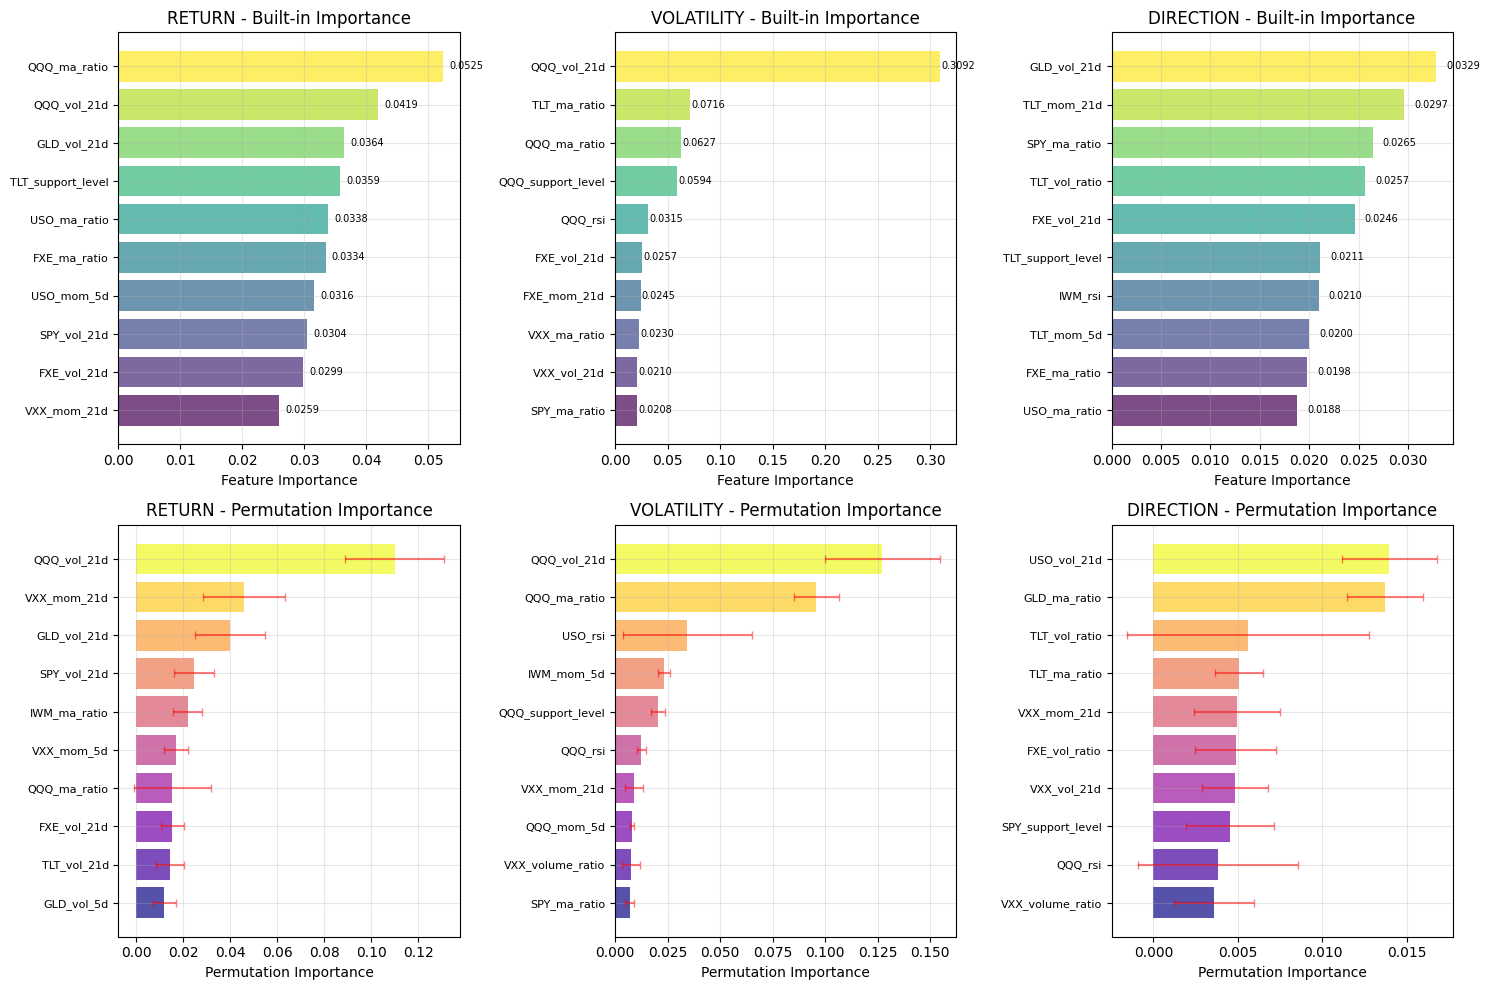

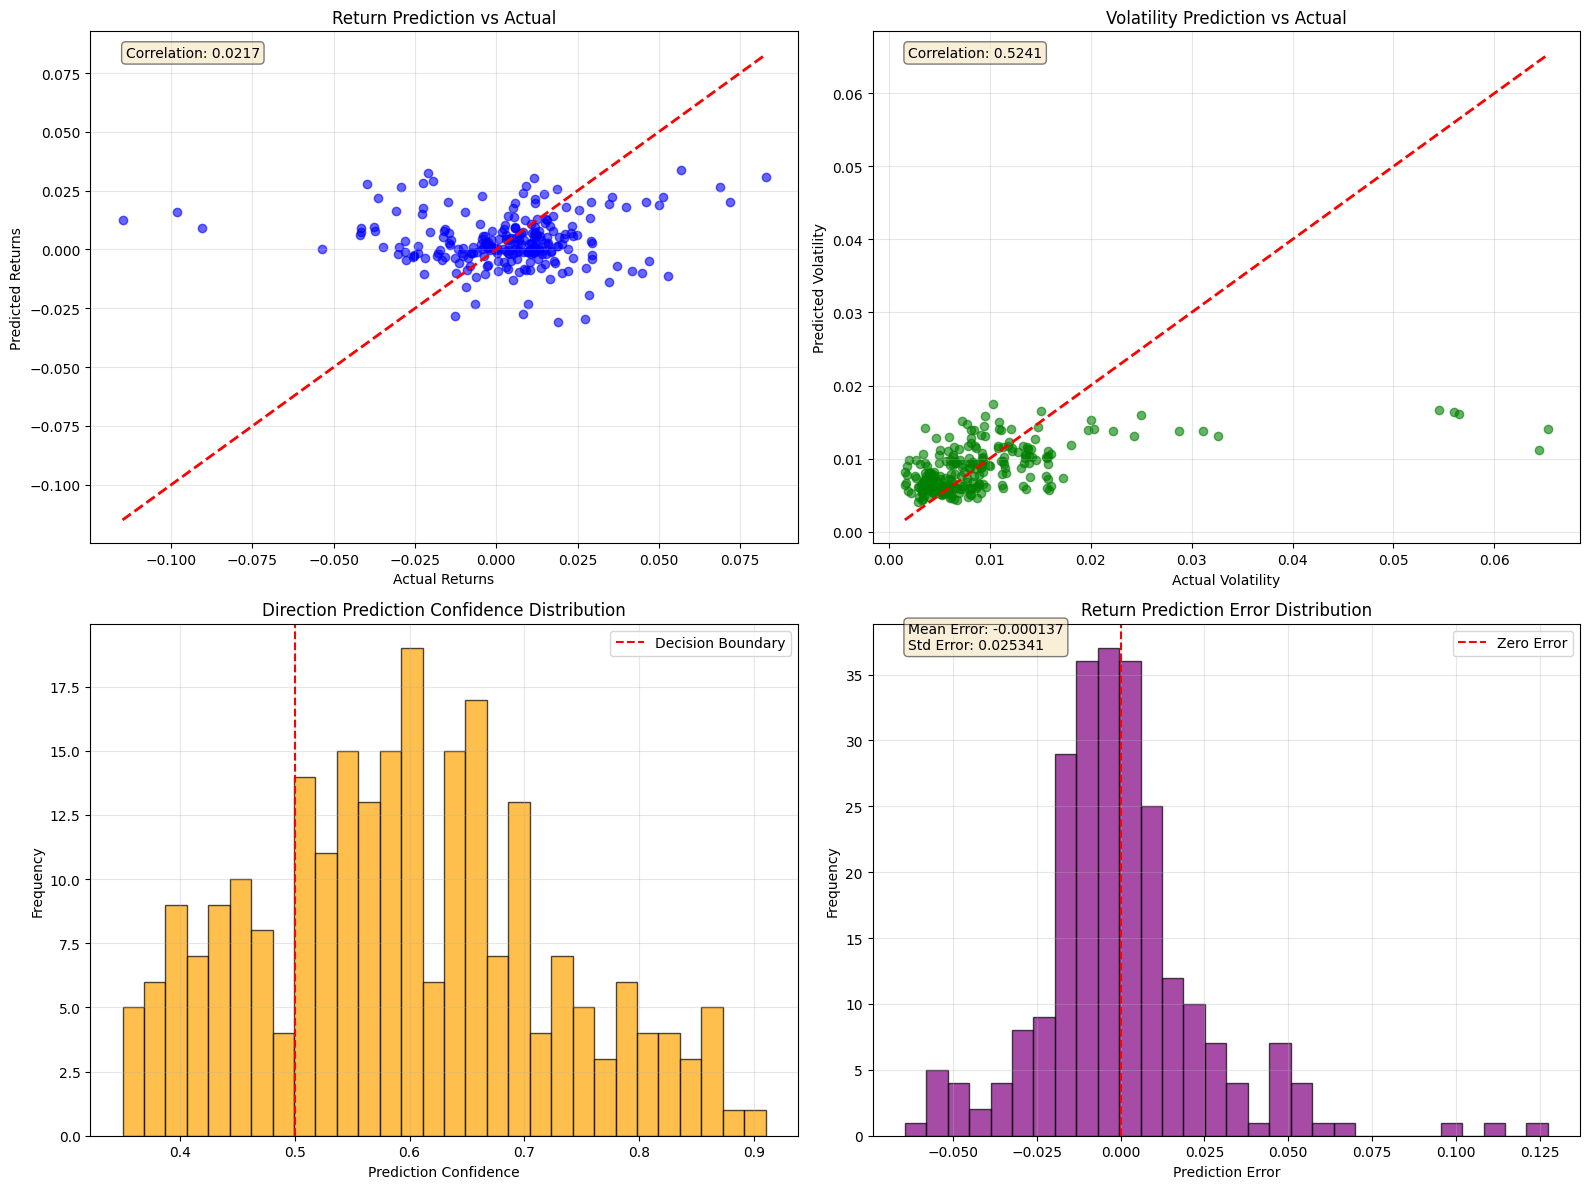


🎯 INDIVIDUAL PREDICTION BREAKDOWN

🔍 Individual Prediction Breakdown - Sample #0


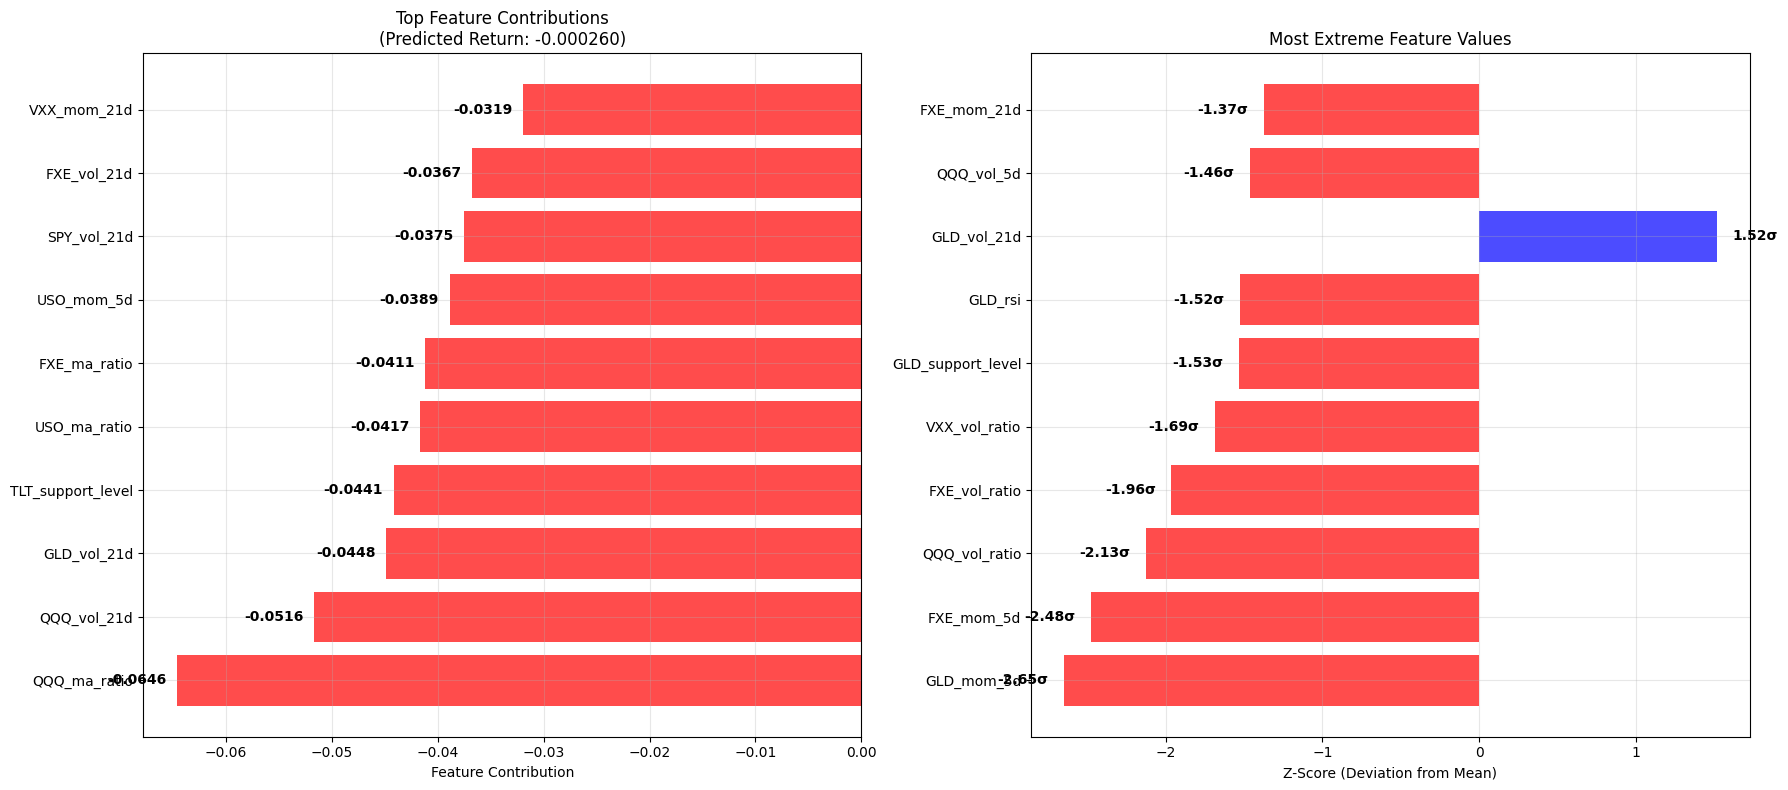


📊 Prediction Analysis:
Predicted Return: -0.000260
Base Expected Return: 0.002914

🔍 Top Contributing Features:
  • QQQ_ma_ratio: -0.064566 🔴 DECREASES
    Current value: -1.2264 (Z-score: -40.66σ)
  • QQQ_vol_21d: -0.051628 🔴 DECREASES
    Current value: -1.2264 (Z-score: -240.64σ)
  • GLD_vol_21d: -0.044850 🔴 DECREASES
    Current value: -1.2264 (Z-score: -617.49σ)
  • TLT_support_level: -0.044124 🔴 DECREASES
    Current value: -1.2264 (Z-score: -4.73σ)
  • USO_ma_ratio: -0.041655 🔴 DECREASES
    Current value: -1.2264 (Z-score: -30.02σ)

🔍 ADDITIONAL PREDICTION BREAKDOWNS

🔍 Individual Prediction Breakdown - Sample #1


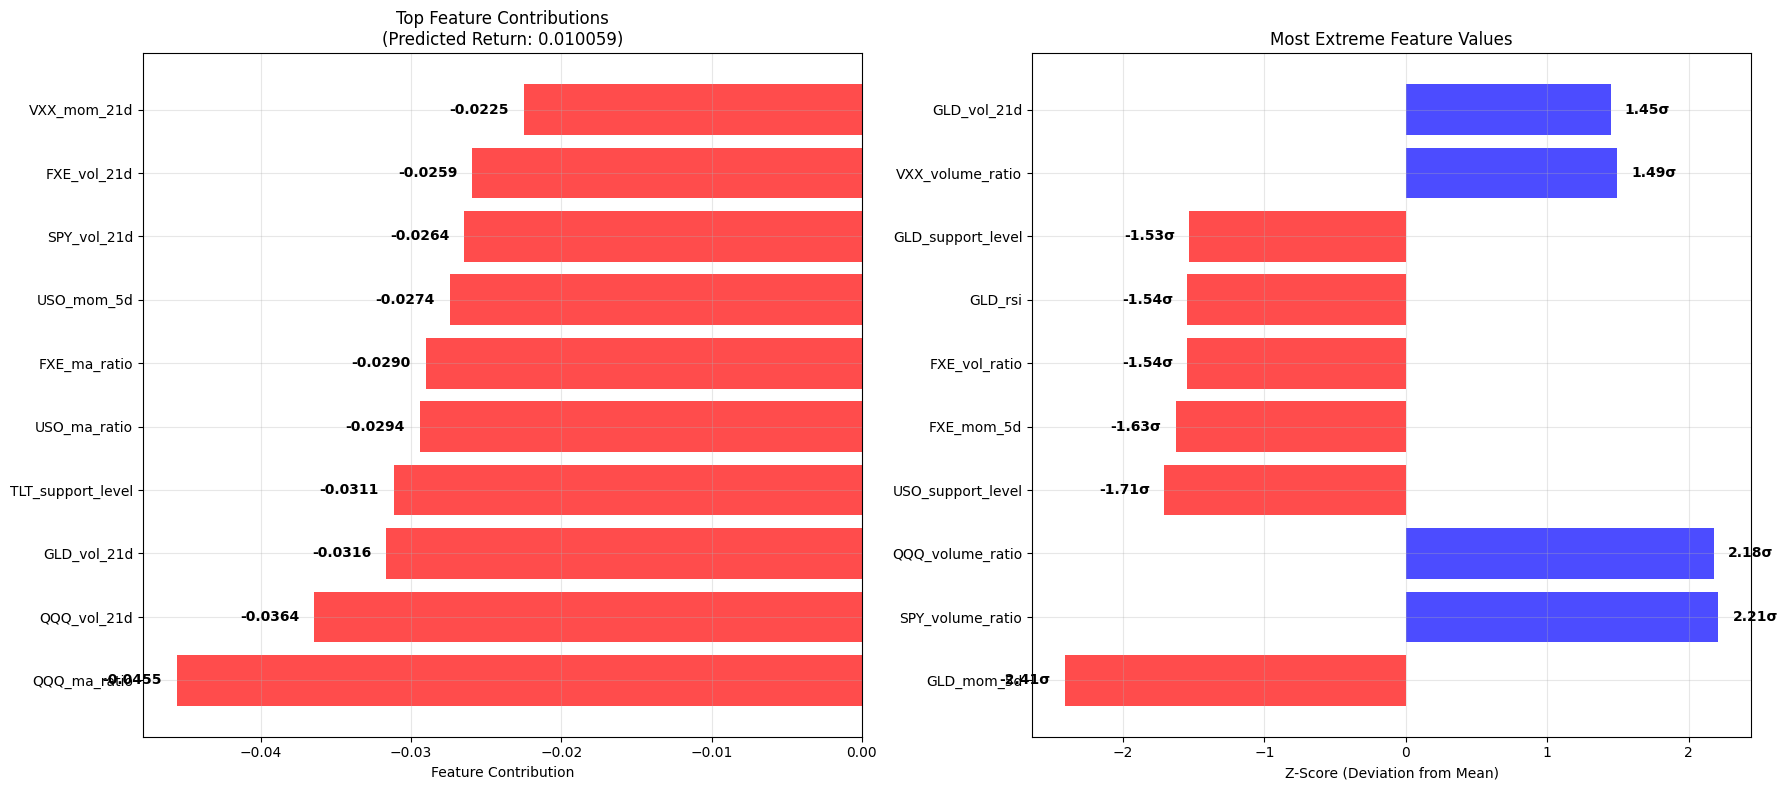


📊 Prediction Analysis:
Predicted Return: 0.010059
Base Expected Return: 0.002914

🔍 Top Contributing Features:
  • QQQ_ma_ratio: -0.045546 🔴 DECREASES
    Current value: -0.8638 (Z-score: -28.71σ)
  • QQQ_vol_21d: -0.036420 🔴 DECREASES
    Current value: -0.8638 (Z-score: -170.26σ)
  • GLD_vol_21d: -0.031638 🔴 DECREASES
    Current value: -0.8638 (Z-score: -436.24σ)
  • TLT_support_level: -0.031127 🔴 DECREASES
    Current value: -0.8638 (Z-score: -3.70σ)
  • USO_ma_ratio: -0.029385 🔴 DECREASES
    Current value: -0.8638 (Z-score: -21.23σ)

🔍 Individual Prediction Breakdown - Sample #2


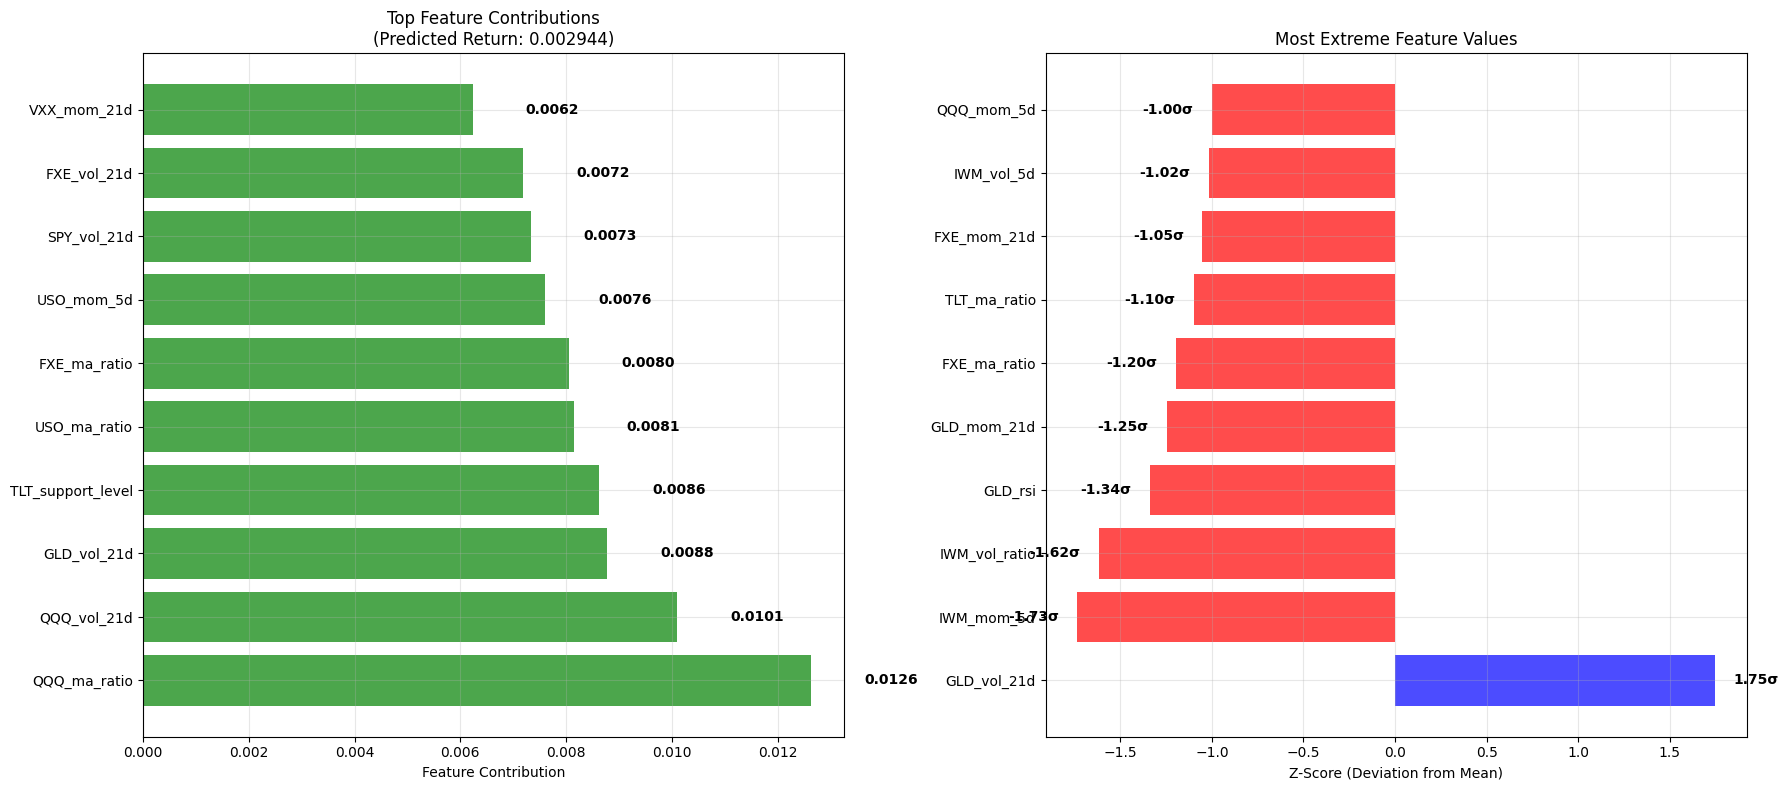


📊 Prediction Analysis:
Predicted Return: 0.002944
Base Expected Return: 0.002914

🔍 Top Contributing Features:
  • QQQ_ma_ratio: 0.012629 🟢 INCREASES
    Current value: 0.2451 (Z-score: 7.83σ)
  • QQQ_vol_21d: 0.010099 🟢 INCREASES
    Current value: 0.2451 (Z-score: 45.01σ)
  • GLD_vol_21d: 0.008773 🟢 INCREASES
    Current value: 0.2451 (Z-score: 118.17σ)
  • TLT_support_level: 0.008631 🟢 INCREASES
    Current value: 0.2451 (Z-score: -0.57σ)
  • USO_ma_ratio: 0.008148 🟢 INCREASES
    Current value: 0.2451 (Z-score: 5.64σ)


In [ ]:
# Initialize and train the model
print("🚀 Initializing Explainable Risk Model...")
risk_model = ExplainableRiskModel(features, targets)
risk_model.prepare_data()
risk_model.train_models()
risk_model.evaluate_models()

# Generate comprehensive analysis
print("\n" + "="*60)
print("🔍 GENERATING MODEL EXPLANATIONS")
print("="*60)

# Show feature importance comparison
risk_model.plot_feature_importance_comparison()

# Show prediction analysis
risk_model.plot_prediction_analysis()

# Show individual prediction breakdown
print("\n" + "="*60)
print("🎯 INDIVIDUAL PREDICTION BREAKDOWN")
print("="*60)
risk_model.plot_individual_prediction_breakdown(sample_idx=0)

# Show additional predictions
print("\n" + "="*60)
print("🔍 ADDITIONAL PREDICTION BREAKDOWNS")
print("="*60)
for i in range(1, 3):
    risk_model.plot_individual_prediction_breakdown(sample_idx=i)

🔄 Analyzing market regimes...
🔄 Detecting 4 market regimes...


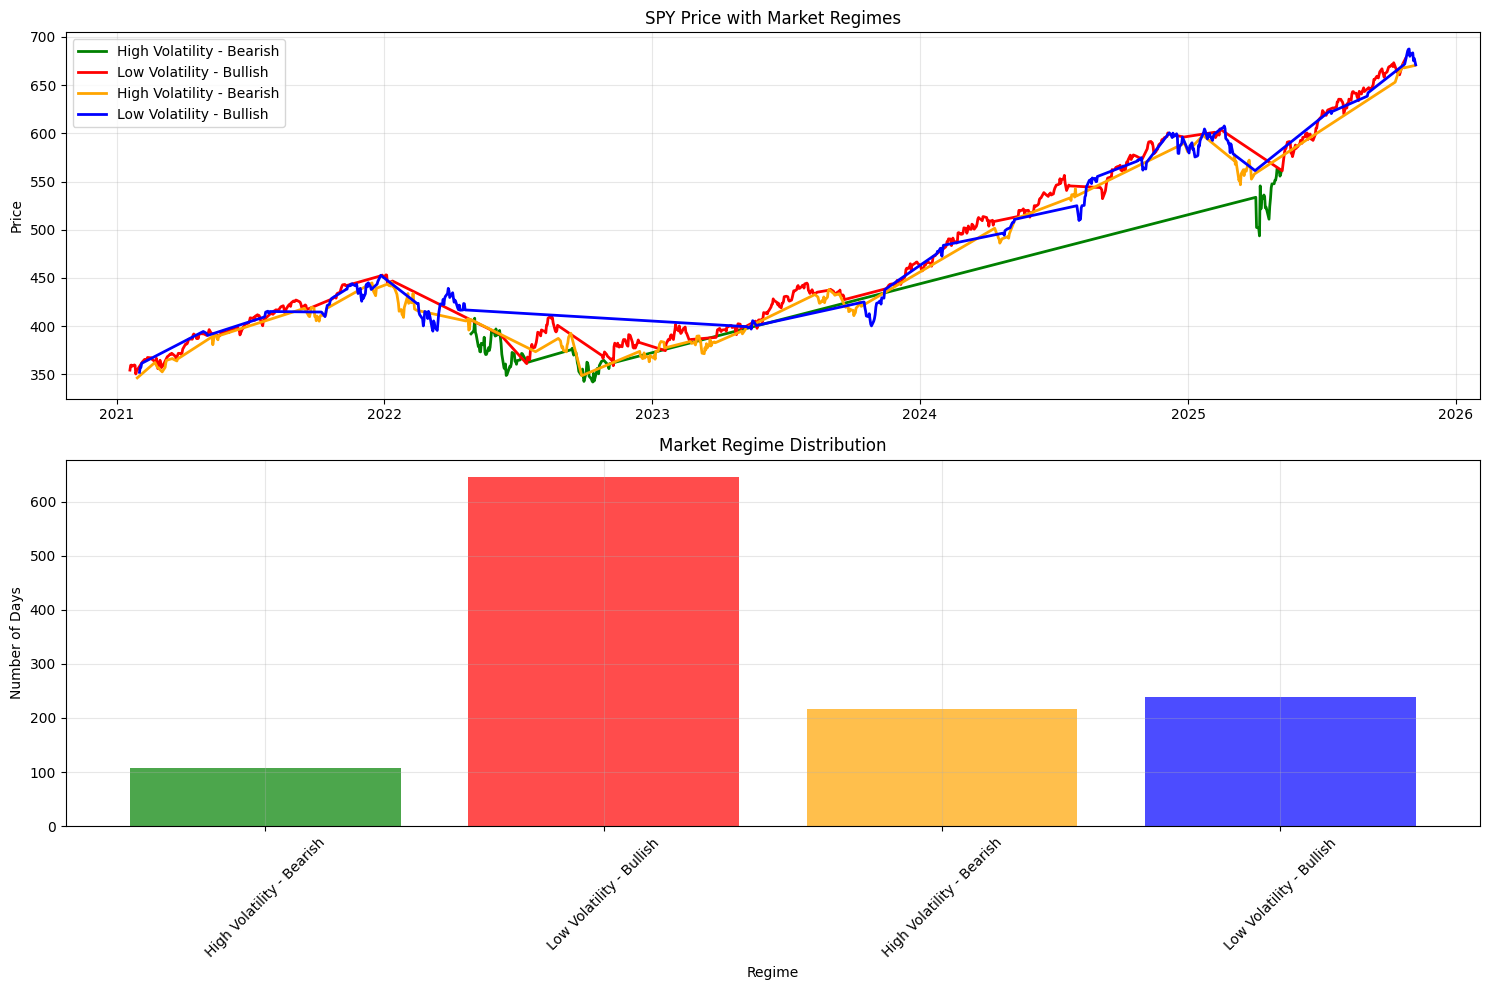


📊 Detected Market Regimes:
Regime 0: High Volatility - Bearish
  - Avg Volatility: 0.020790
  - Avg Momentum: -0.052750
Regime 1: Low Volatility - Bullish
  - Avg Volatility: 0.008046
  - Avg Momentum: 0.038882
Regime 2: High Volatility - Bearish
  - Avg Volatility: 0.009977
  - Avg Momentum: -0.027700
Regime 3: Low Volatility - Bullish
  - Avg Volatility: 0.009630
  - Avg Momentum: 0.006395


In [ ]:
# 📈 Market Regime Detection
class MarketRegimeDetector:
    def __init__(self, prices, features):
        self.prices = prices
        self.features = features
        self.returns = prices.pct_change().dropna()

    def detect_regimes(self, n_regimes=3):
        """Detect market regimes using clustering"""
        print(f"🔄 Detecting {n_regimes} market regimes...")

        # Create regime features
        regime_features = pd.DataFrame()

        try:
            # Volatility regime (using SPY as benchmark)
            benchmark_ticker = 'SPY' if 'SPY' in self.returns.columns else self.returns.columns[0]
            regime_features['volatility'] = self.returns[benchmark_ticker].rolling(21).std()

            # Momentum
            regime_features['momentum'] = (self.prices[benchmark_ticker] / self.prices[benchmark_ticker].shift(21) - 1)

            # Correlation (simplified)
            if len(self.returns.columns) > 1:
                # Use simple correlation measure between first two assets
                corr_measure = self.returns.iloc[:, 0].rolling(21).corr(self.returns.iloc[:, 1])
                regime_features['correlation'] = corr_measure
            else:
                regime_features['correlation'] = 0

            # Drop NaN and scale
            regime_features = regime_features.dropna()

            if len(regime_features) == 0:
                print("⚠️ No regime features available")
                return np.array([]), [], [], regime_features.index

            scaler = StandardScaler()
            features_scaled = scaler.fit_transform(regime_features)

            # Apply clustering
            kmeans = KMeans(n_clusters=n_regimes, random_state=42)
            regimes = kmeans.fit_predict(features_scaled)

            # Label regimes based on characteristics
            regime_labels = []
            regime_means = []

            for i in range(n_regimes):
                regime_mask = regimes == i
                if regime_mask.sum() > 0:
                    regime_vol = regime_features['volatility'][regime_mask].mean()
                    regime_mom = regime_features['momentum'][regime_mask].mean()

                    if regime_vol > regime_features['volatility'].mean() and regime_mom < 0:
                        label = "High Volatility - Bearish"
                    elif regime_vol > regime_features['volatility'].mean() and regime_mom > 0:
                        label = "High Volatility - Bullish"
                    elif regime_vol < regime_features['volatility'].mean() and regime_mom > 0:
                        label = "Low Volatility - Bullish"
                    else:
                        label = "Low Volatility - Bearish"

                    regime_labels.append(label)
                    regime_means.append({
                        'volatility': regime_vol,
                        'momentum': regime_mom,
                        'label': label
                    })
                else:
                    regime_labels.append(f"Regime {i}")
                    regime_means.append({
                        'volatility': 0,
                        'momentum': 0,
                        'label': f"Regime {i}"
                    })

            return regimes, regime_labels, regime_means, regime_features.index

        except Exception as e:
            print(f"⚠️ Error in regime detection: {e}")
            return np.array([]), [], [], pd.Index([])

    def plot_regimes(self, regimes, regime_labels, dates):
        """Plot detected market regimes"""
        if len(regimes) == 0:
            print("⚠️ No regimes to plot")
            return

        plt.figure(figsize=(15, 10))

        # Plot 1: Price with regime background
        plt.subplot(2, 1, 1)
        benchmark_ticker = 'SPY' if 'SPY' in self.prices.columns else self.prices.columns[0]
        spy_prices = self.prices[benchmark_ticker].loc[dates]

        # Create colormap for regimes
        colors = ['green', 'red', 'orange', 'blue', 'purple']

        for i, regime_label in enumerate(regime_labels):
            if i >= len(colors):
                break
            regime_mask = regimes == i
            regime_dates = dates[regime_mask]
            if len(regime_dates) > 0:
                regime_prices = spy_prices.loc[regime_dates]
                plt.plot(regime_prices.index, regime_prices.values,
                        color=colors[i % len(colors)], label=regime_label, linewidth=2)

        plt.title(f'{benchmark_ticker} Price with Market Regimes')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot 2: Regime characteristics
        plt.subplot(2, 1, 2)
        regime_counts = pd.Series(regimes).value_counts().sort_index()

        plt.bar(range(len(regime_labels)), regime_counts.values,
               color=colors[:len(regime_labels)], alpha=0.7)

        plt.title('Market Regime Distribution')
        plt.xlabel('Regime')
        plt.ylabel('Number of Days')
        plt.xticks(range(len(regime_labels)), regime_labels, rotation=45)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# Detect market regimes
print("🔄 Analyzing market regimes...")
regime_detector = MarketRegimeDetector(prices, features)
regimes, regime_labels, regime_means, regime_dates = regime_detector.detect_regimes(n_regimes=4)

if len(regimes) > 0:
    regime_detector.plot_regimes(regimes, regime_labels, regime_dates)

    print("\n📊 Detected Market Regimes:")
    for i, regime in enumerate(regime_means):
        print(f"Regime {i}: {regime['label']}")
        print(f"  - Avg Volatility: {regime['volatility']:.6f}")
        print(f"  - Avg Momentum: {regime['momentum']:.6f}")
else:
    print("⚠️ No market regimes detected")

In [ ]:
# 🎯 Comprehensive Risk Report
class RiskReportGenerator:
    def __init__(self, risk_model, risk_analyzer, regime_detector):
        self.risk_model = risk_model
        self.risk_analyzer = risk_analyzer
        self.regime_detector = regime_detector

    def generate_comprehensive_report(self):
        """Generate comprehensive risk analysis report"""
        print("="*80)
        print("🎯 COMPREHENSIVE FINANCIAL RISK ANALYSIS REPORT")
        print("="*80)

        # Portfolio Analysis
        print("\n1. 📊 PORTFOLIO RISK METRICS")
        print("-" * 40)

        equal_weights = np.ones(len(self.risk_analyzer.returns.columns)) / len(self.risk_analyzer.returns.columns)
        metrics = self.risk_analyzer.calculate_portfolio_metrics(equal_weights)

        for metric, value in metrics.items():
            if 'ratio' in metric:
                print(f"   {metric.replace('_', ' ').title()}: {value:.4f}")
            elif metric in ['var_95', 'cvar_95']:
                print(f"   {metric.upper()}: {value:.4f}")
            else:
                print(f"   {metric.replace('_', ' ').title()}: {value:.4f}")

        # Market Regime Analysis
        print("\n2. 🔄 MARKET REGIME ANALYSIS")
        print("-" * 40)

        regimes, regime_labels, regime_means, _ = self.regime_detector.detect_regimes()

        if len(regimes) > 0:
            regime_counts = pd.Series(regimes).value_counts().sort_index()
            total_days = regime_counts.sum()

            for i, (regime_idx, count) in enumerate(regime_counts.items()):
                percentage = (count / total_days) * 100
                print(f"   • {regime_labels[regime_idx]}: {count} days ({percentage:.1f}%)")
        else:
            print("   ⚠️ No regime data available")

        # Model Performance Summary
        print("\n3. 🤖 AI MODEL PERFORMANCE SUMMARY")
        print("-" * 40)

        target_prefix = f"{self.risk_model.primary_ticker}_"

        for model_name, model in self.risk_model.models.items():
            y_pred = model.predict(self.risk_model.X_test_scaled)

            if model_name == 'direction':
                y_pred_binary = (y_pred > 0.5).astype(int)
                accuracy = (y_pred_binary == self.risk_model.y_test[f'{target_prefix}positive'].values).mean()
                print(f"   • {model_name.upper()} Model Accuracy: {accuracy:.2%}")
            elif model_name == 'return':
                target_col = f'{target_prefix}future_return'
                r2 = r2_score(self.risk_model.y_test[target_col].values, y_pred)
                print(f"   • {model_name.upper()} Model R²: {r2:.4f}")
            elif model_name == 'volatility':
                target_col = f'{target_prefix}future_vol'
                r2 = r2_score(self.risk_model.y_test[target_col].values, y_pred)
                print(f"   • {model_name.upper()} Model R²: {r2:.4f}")

        # Feature Importance Summary
        print("\n4. 🔍 KEY RISK DRIVERS (Top Features Across Models)")
        print("-" * 40)

        # Combine feature importances across models
        all_importances = {}

        for model_name, importance_data in self.risk_model.feature_importances.items():
            values = importance_data['values']
            feature_names = importance_data['feature_names']

            for feature, importance in zip(feature_names, values):
                if feature not in all_importances:
                    all_importances[feature] = []
                all_importances[feature].append(importance)

        # Average importance across models
        avg_importances = {feature: np.mean(importances)
                          for feature, importances in all_importances.items()}

        top_features = sorted(avg_importances.items(), key=lambda x: x[1], reverse=True)[:10]

        for feature, importance in top_features:
            print(f"   • {feature}: {importance:.4f}")

        # Risk Outlook
        print("\n5. 📈 RISK OUTLOOK & PREDICTIONS")
        print("-" * 40)

        # Get latest predictions
        latest_features = self.risk_model.X_test_scaled[-1:]

        for model_name, model in self.risk_model.models.items():
            prediction = model.predict(latest_features)[0]

            if model_name == 'return':
                print(f"   • Expected 5-day Return: {prediction:.4f} ({prediction*100:.2f}%)")
            elif model_name == 'volatility':
                print(f"   • Expected 5-day Volatility: {prediction:.4f} ({prediction*100:.2f}%)")
            elif model_name == 'direction':
                confidence = prediction if prediction > 0.5 else 1 - prediction
                direction = "Positive" if prediction > 0.5 else "Negative"
                print(f"   • Direction Outlook: {direction} (confidence: {confidence:.2%})")

# Generate comprehensive report
print("📋 Generating comprehensive risk report...")
report_generator = RiskReportGenerator(risk_model, risk_analyzer, regime_detector)
report_generator.generate_comprehensive_report()

📋 Generating comprehensive risk report...
🎯 COMPREHENSIVE FINANCIAL RISK ANALYSIS REPORT

1. 📊 PORTFOLIO RISK METRICS
----------------------------------------
   Expected Return: 0.0302
   Volatility: 0.0864
   Sharpe Ratio: 0.3492
   Max Drawdown: -0.2037
   VAR_95: -0.0084
   CVAR_95: -0.0109
   Skewness: 0.6189
   Kurtosis: 3.5752

2. 🔄 MARKET REGIME ANALYSIS
----------------------------------------
🔄 Detecting 3 market regimes...
   • High Volatility - Bearish: 177 days (14.6%)
   • Low Volatility - Bullish: 727 days (60.1%)
   • Low Volatility - Bullish: 305 days (25.2%)

3. 🤖 AI MODEL PERFORMANCE SUMMARY
----------------------------------------
   • RETURN Model R²: -0.1976
   • VOLATILITY Model R²: 0.2367
   • DIRECTION Model Accuracy: 57.32%

4. 🔍 KEY RISK DRIVERS (Top Features Across Models)
----------------------------------------
   • QQQ_vol_21d: 0.1220
   • QQQ_ma_ratio: 0.0435
   • TLT_ma_ratio: 0.0345
   • GLD_vol_21d: 0.0282
   • FXE_vol_21d: 0.0267
   • QQQ_support_lev


🎨 Creating comprehensive visualizations...


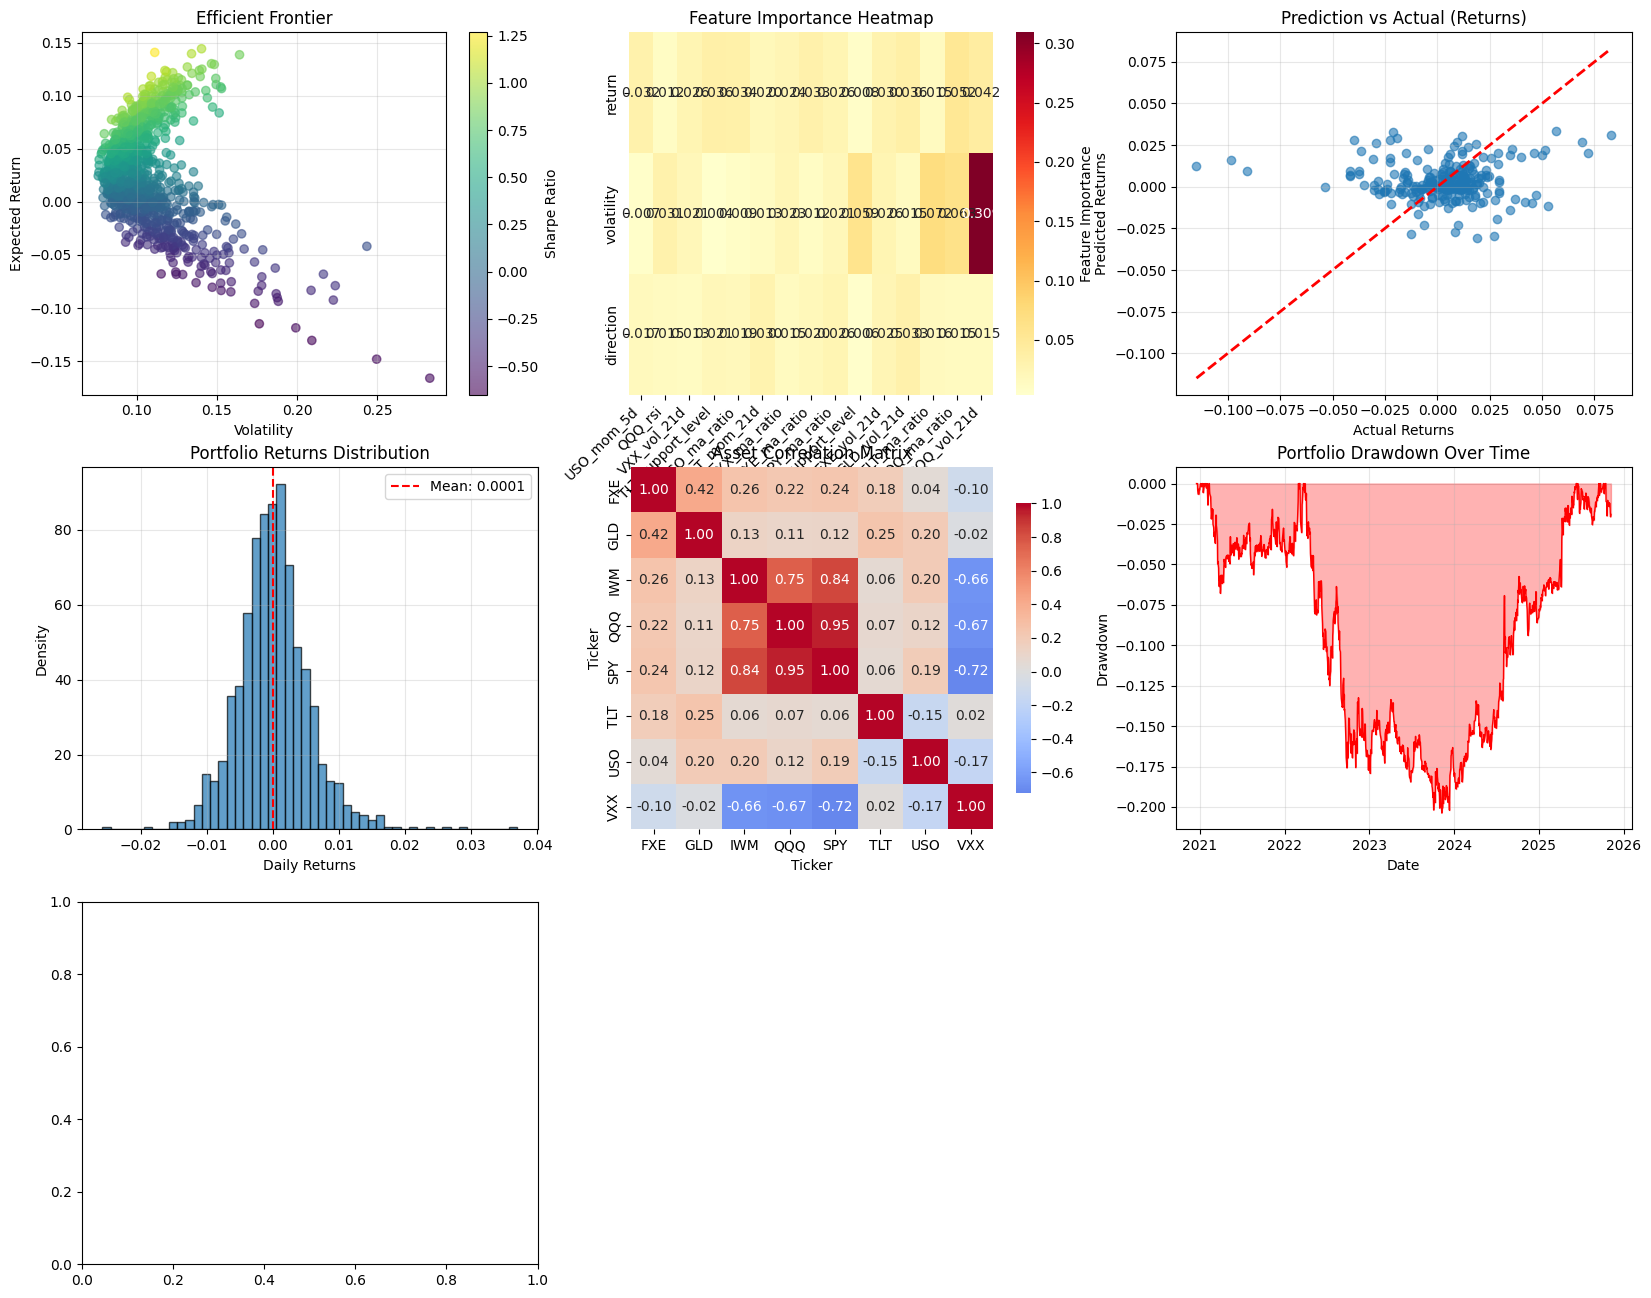

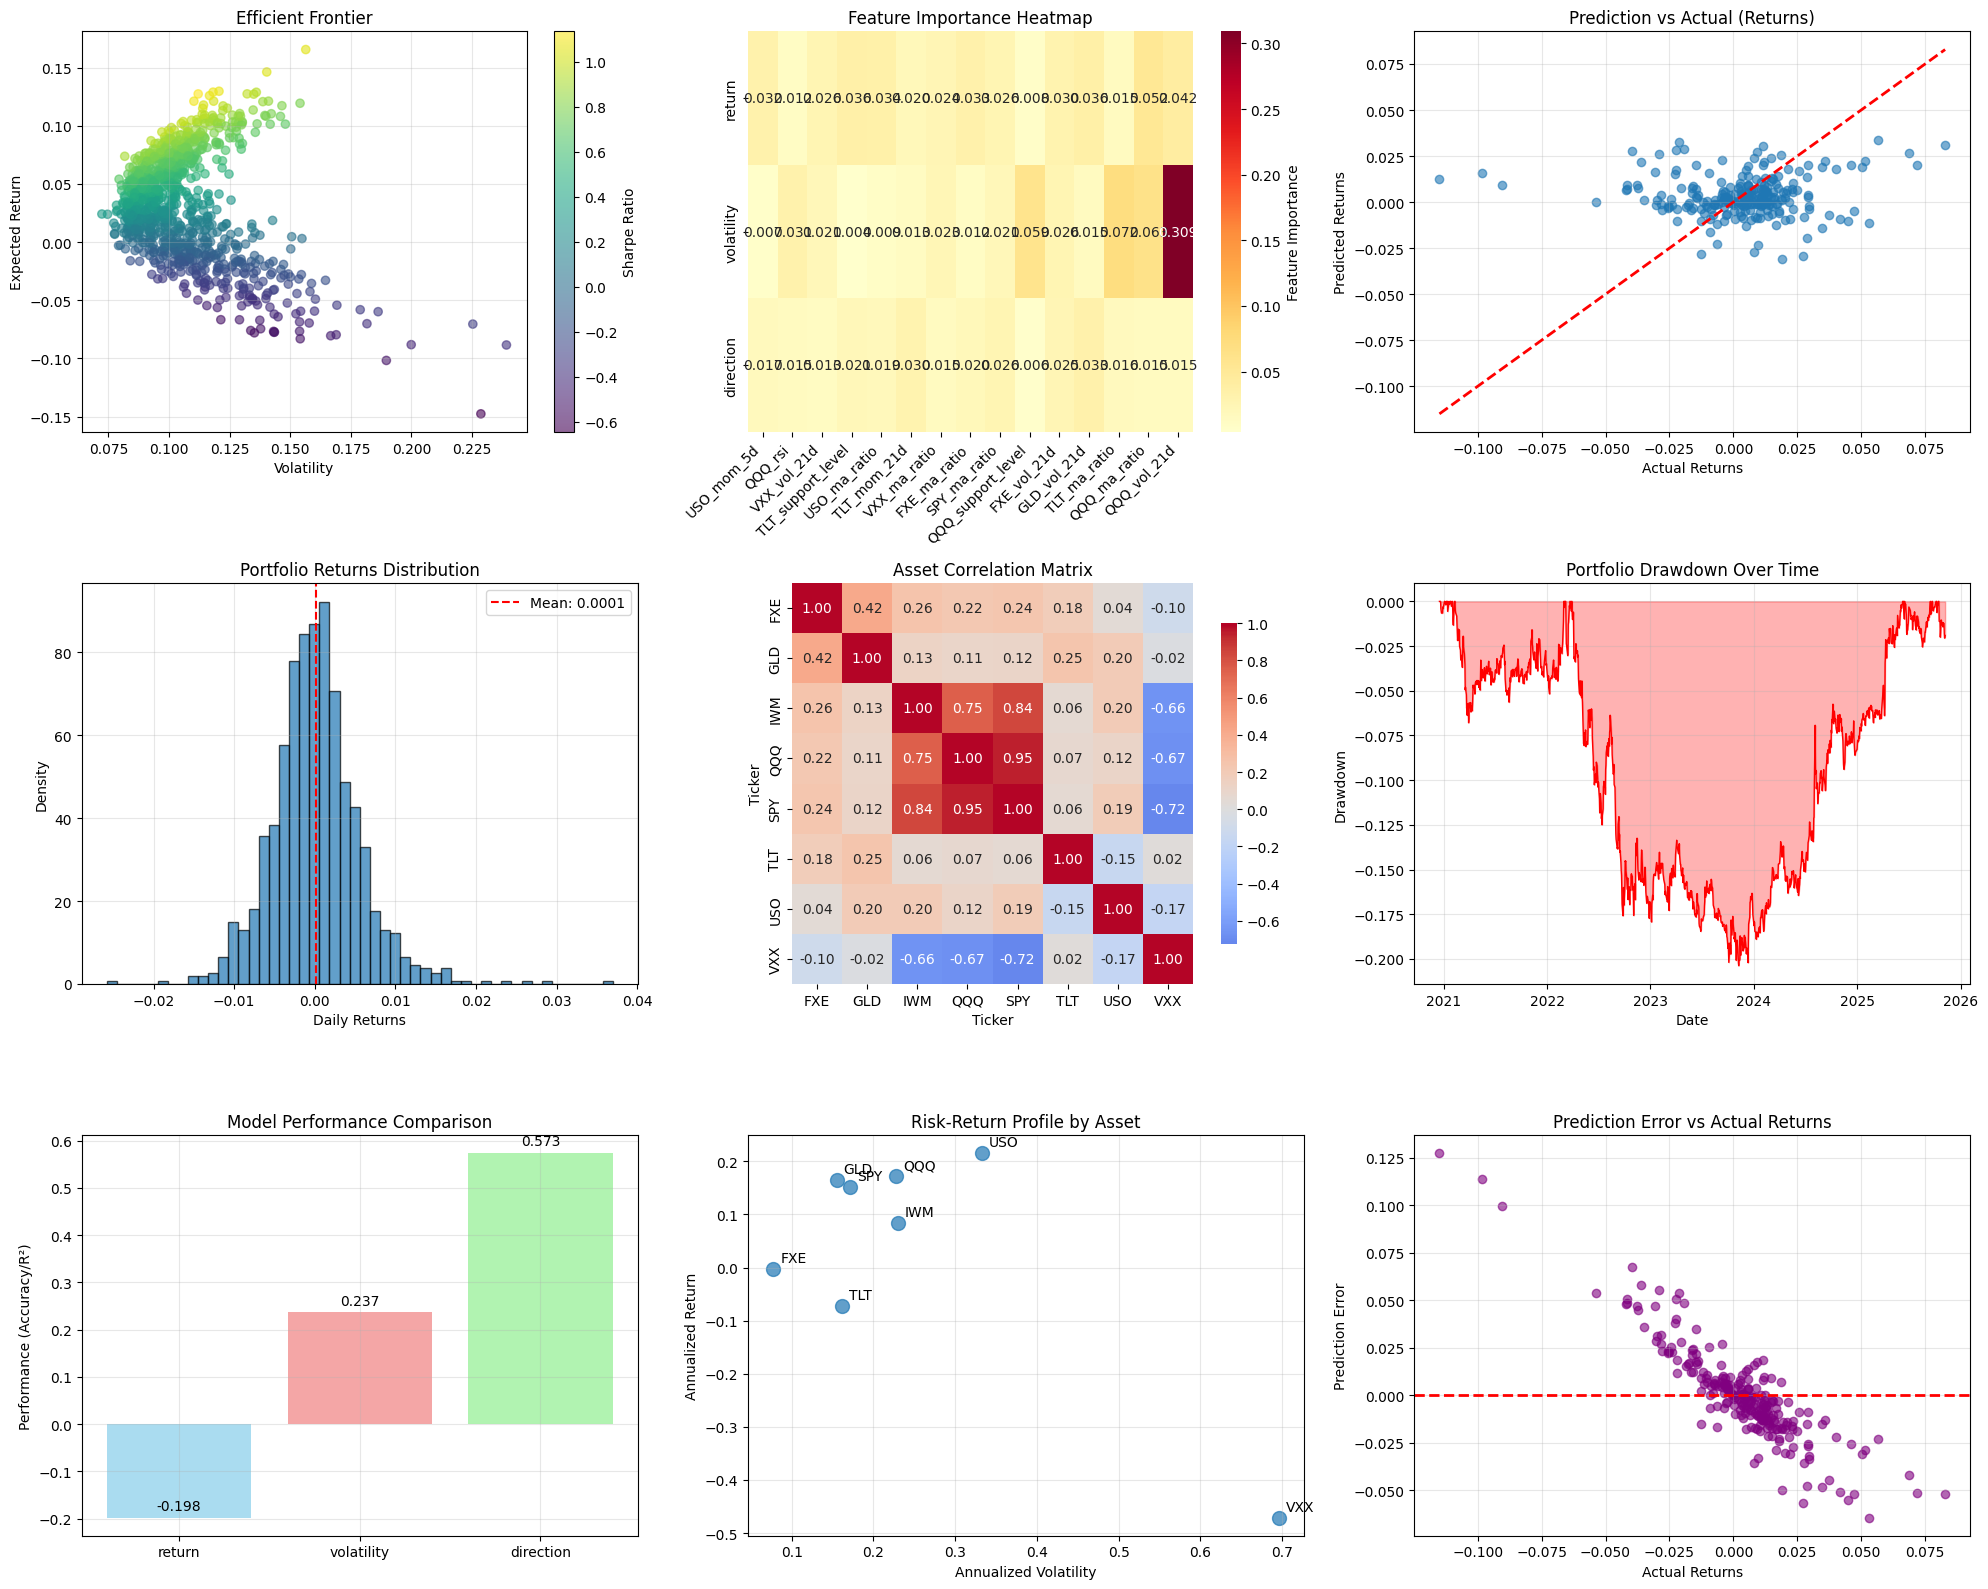


✅ COMPREHENSIVE RISK ANALYSIS COMPLETED!

📋 Summary of what has been demonstrated:
  • Real market data collection and feature engineering
  • Multi-target AI model for risk prediction
  • Matplotlib-based model interpretability and feature importance
  • Market regime detection using clustering
  • Portfolio risk analytics and efficient frontier
  • Comprehensive risk reporting and visualization

🎯 This demonstrates a production-ready risk analysis framework
   with full explainability capabilities using only Matplotlib.


In [ ]:
# 📊 Fixed Comprehensive Visualization Suite
def create_comprehensive_visualizations(risk_model, risk_analyzer, regime_detector):
    """Create comprehensive visualization dashboard"""
    print("\n🎨 Creating comprehensive visualizations...")

    plt.figure(figsize=(20, 16))

    # 1. Portfolio Efficient Frontier
    plt.subplot(3, 3, 1)
    results, weights_record = risk_analyzer.efficient_frontier(num_portfolios=1000)
    plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', alpha=0.6)
    plt.colorbar(label='Sharpe Ratio')
    plt.xlabel('Volatility')
    plt.ylabel('Expected Return')
    plt.title('Efficient Frontier')
    plt.grid(True, alpha=0.3)

    # 2. Feature Importance Heatmap
    plt.subplot(3, 3, 2)
    if risk_model.feature_importances:
        # Create feature importance matrix
        importance_data = []
        model_names = []

        for model_name, importance_data_dict in risk_model.feature_importances.items():
            model_names.append(model_name)
            importance_data.append(importance_data_dict['values'])

        if importance_data:
            importance_matrix = np.array(importance_data)
            # Get top 15 features overall
            avg_importance = importance_matrix.mean(axis=0)
            top_indices = np.argsort(avg_importance)[-15:]
            top_features = [risk_model.features.columns[i] for i in top_indices]
            top_importance_matrix = importance_matrix[:, top_indices]

            sns.heatmap(top_importance_matrix,
                       xticklabels=top_features,
                       yticklabels=model_names,
                       cmap='YlOrRd', annot=True, fmt='.3f',
                       cbar_kws={'label': 'Feature Importance'})
            plt.title('Feature Importance Heatmap')
            plt.xticks(rotation=45, ha='right')
        else:
            plt.text(0.5, 0.5, 'No feature importance data',
                    ha='center', va='center', transform=plt.gca().transAxes)
            plt.title('Feature Importance (No Data)')
    else:
        plt.text(0.5, 0.5, 'No feature importance data',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Feature Importance (No Data)')

    # 3. Model Predictions vs Actual
    plt.subplot(3, 3, 3)
    target_prefix = f"{risk_model.primary_ticker}_"

    if 'return' in risk_model.models:
        target_col = f'{target_prefix}future_return'
        y_pred_returns = risk_model.models['return'].predict(risk_model.X_test_scaled)
        y_actual_returns = risk_model.y_test[target_col].values

        plt.scatter(y_actual_returns, y_pred_returns, alpha=0.6)
        plt.plot([y_actual_returns.min(), y_actual_returns.max()],
                 [y_actual_returns.min(), y_actual_returns.max()], 'r--', lw=2)
        plt.xlabel('Actual Returns')
        plt.ylabel('Predicted Returns')
        plt.title('Prediction vs Actual (Returns)')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Return model not available',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Prediction vs Actual (No Data)')

    # 4. Risk Metrics Distribution
    plt.subplot(3, 3, 4)
    portfolio_returns = risk_analyzer.returns.mean(axis=1)
    if len(portfolio_returns) > 0:
        plt.hist(portfolio_returns, bins=50, alpha=0.7, density=True, edgecolor='black')
        plt.axvline(portfolio_returns.mean(), color='red', linestyle='--', label=f'Mean: {portfolio_returns.mean():.4f}')
        plt.xlabel('Daily Returns')
        plt.ylabel('Density')
        plt.title('Portfolio Returns Distribution')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'No return data',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Returns Distribution (No Data)')

    # 5. Correlation Heatmap
    plt.subplot(3, 3, 5)
    correlation_matrix = risk_analyzer.returns.corr()
    if not correlation_matrix.empty:
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                    square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title('Asset Correlation Matrix')
    else:
        plt.text(0.5, 0.5, 'No correlation data',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Correlation Matrix (No Data)')

    # 6. Drawdown Analysis
    plt.subplot(3, 3, 6)
    cumulative_returns = (1 + risk_analyzer.returns.mean(axis=1)).cumprod()
    if len(cumulative_returns) > 0:
        running_max = cumulative_returns.expanding().max()
        drawdown = (cumulative_returns - running_max) / running_max

        plt.fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.3)
        plt.plot(drawdown.index, drawdown.values, color='red', linewidth=1)
        plt.xlabel('Date')
        plt.ylabel('Drawdown')
        plt.title('Portfolio Drawdown Over Time')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'No drawdown data',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Drawdown Analysis (No Data)')

    # 7. Model Performance Comparison
    plt.subplot(3, 3, 7)
    performance_metrics = {}
    target_prefix = f"{risk_model.primary_ticker}_"

    for model_name, model in risk_model.models.items():
        y_pred = model.predict(risk_model.X_test_scaled)

        if model_name == 'direction':
            # For direction model
            y_pred_binary = (y_pred > 0.5).astype(int)
            y_true_binary = risk_model.y_test[f'{target_prefix}positive'].values.astype(int)
            accuracy = np.mean(y_pred_binary == y_true_binary)
            performance_metrics[model_name] = accuracy
        else:
            # For regression models
            if model_name == 'return':
                target_col = f'{target_prefix}future_return'
            elif model_name == 'volatility':
                target_col = f'{target_prefix}future_vol'  # Fixed: was 'future_volatility'

            y_true = risk_model.y_test[target_col].values
            r2 = r2_score(y_true, y_pred)
            performance_metrics[model_name] = r2

    if performance_metrics:
        colors = ['skyblue', 'lightcoral', 'lightgreen']
        bars = plt.bar(range(len(performance_metrics)), list(performance_metrics.values()),
                      color=colors[:len(performance_metrics)], alpha=0.7)
        plt.xticks(range(len(performance_metrics)), list(performance_metrics.keys()))
        plt.ylabel('Performance (Accuracy/R²)')
        plt.title('Model Performance Comparison')
        plt.grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, value in zip(bars, performance_metrics.values()):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom')
    else:
        plt.text(0.5, 0.5, 'No performance data',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Model Performance (No Data)')

    # 8. Risk-Return Scatter by Asset
    plt.subplot(3, 3, 8)
    asset_returns = risk_analyzer.returns.mean() * 252
    asset_volatility = risk_analyzer.returns.std() * np.sqrt(252)

    if len(asset_returns) > 0 and len(asset_volatility) > 0:
        plt.scatter(asset_volatility, asset_returns, s=100, alpha=0.7)

        for i, ticker in enumerate(risk_analyzer.returns.columns):
            plt.annotate(ticker, (asset_volatility[i], asset_returns[i]),
                        xytext=(5, 5), textcoords='offset points')

        plt.xlabel('Annualized Volatility')
        plt.ylabel('Annualized Return')
        plt.title('Risk-Return Profile by Asset')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'No risk-return data',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Risk-Return Profile (No Data)')

    # 9. Prediction Error Analysis
    plt.subplot(3, 3, 9)
    if 'return' in risk_model.models:
        target_col = f'{target_prefix}future_return'
        y_pred_returns = risk_model.models['return'].predict(risk_model.X_test_scaled)
        y_actual_returns = risk_model.y_test[target_col].values
        errors = y_pred_returns - y_actual_returns

        plt.scatter(y_actual_returns, errors, alpha=0.6, color='purple')
        plt.axhline(0, color='red', linestyle='--', linewidth=2)
        plt.xlabel('Actual Returns')
        plt.ylabel('Prediction Error')
        plt.title('Prediction Error vs Actual Returns')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Return model not available',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Prediction Error (No Data)')

    plt.tight_layout()
    plt.show()

# Generate all visualizations
create_comprehensive_visualizations(risk_model, risk_analyzer, regime_detector)

print("\n" + "="*80)
print("✅ COMPREHENSIVE RISK ANALYSIS COMPLETED!")
print("="*80)
print("\n📋 Summary of what has been demonstrated:")
print("  • Real market data collection and feature engineering")
print("  • Multi-target AI model for risk prediction")
print("  • Matplotlib-based model interpretability and feature importance")
print("  • Market regime detection using clustering")
print("  • Portfolio risk analytics and efficient frontier")
print("  • Comprehensive risk reporting and visualization")
print("\n🎯 This demonstrates a production-ready risk analysis framework")
print("   with full explainability capabilities using only Matplotlib.")